<a href="https://colab.research.google.com/github/itsireneverse-codie/streamlit-Pick0rPass-app/blob/main/TikTok_Content_Engagement_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving tiktok_dataset.csv to tiktok_dataset (1).csv


In [ ]:
import pandas as pd

file_name = 'tiktok_dataset.csv'

df = pd.read_csv(file_name, encoding='latin-1')

df.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries are already happening and will become common by 2025,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more microorganisms in one teaspoon of soil than people on...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industrialist andrew carnegie had a net worth of $475 milli...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,"someone shared with me that the metro of st. petersburg, with an average depth of hundred meters...",not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of businesses allowing employees to bring pets to the wor...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [ ]:
df.shape

(19382, 12)

In [ ]:
df.columns.tolist()

['#',
 'claim_status',
 'video_id',
 'video_duration_sec',
 'video_transcription_text',
 'verified_status',
 'author_ban_status',
 'video_view_count',
 'video_like_count',
 'video_share_count',
 'video_download_count',
 'video_comment_count']

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [ ]:
missing_table = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})

missing_table.sort_values('Missing Values', ascending=False)

,Missing Values,Missing %
claim_status,298,1.54
video_share_count,298,1.54
video_view_count,298,1.54
video_transcription_text,298,1.54
video_download_count,298,1.54
video_comment_count,298,1.54
video_like_count,298,1.54
#,0,0.00
video_duration_sec,0,0.00
video_id,0,0.00


In [ ]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate video IDs:", df['video_id'].duplicated().sum())

Duplicate rows: 0
Duplicate video IDs: 0


In [ ]:
categorical_columns = [
    'claim_status',
    'verified_status',
    'author_ban_status'
]

for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- claim_status ---
claim_status
claim      9608
opinion    9476
NaN         298
Name: count, dtype: int64

--- verified_status ---
verified_status
not verified    18142
verified         1240
Name: count, dtype: int64

--- author_ban_status ---
author_ban_status
active          15663
under review     2080
banned           1639
Name: count, dtype: int64


In [ ]:
numeric_columns = [
    'video_duration_sec',
    'video_view_count',
    'video_like_count',
    'video_share_count',
    'video_download_count',
    'video_comment_count'
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
video_duration_sec,19382.0,32.421732,16.229967,5.0,18.00,32.0,47.00,60.0
video_view_count,19084.0,254708.558688,322893.280814,20.0,4942.50,9954.5,504327.00,999817.0
video_like_count,19084.0,84304.636030,133420.546814,0.0,810.75,3403.5,125020.00,657830.0
video_share_count,19084.0,16735.248323,32036.174350,0.0,115.00,717.0,18222.00,256130.0
video_download_count,19084.0,1049.429627,2004.299894,0.0,7.00,46.0,1156.25,14994.0
video_comment_count,19084.0,349.312146,799.638865,0.0,1.00,9.0,292.00,9599.0


In [ ]:
(df[numeric_columns] < 0).sum()

,0
video_duration_sec,0
video_view_count,0
video_like_count,0
video_share_count,0
video_download_count,0
video_comment_count,0


In [ ]:
(df['video_view_count'] == 0).sum()

np.int64(0)

In [ ]:
missing_rows = df[df.isnull().any(axis=1)]

print("Rows with missing values:", len(missing_rows))

missing_rows.head()

Rows with missing values: 298


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
19084,19085,NaN,4380513697,39,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19085,19086,NaN,8352130892,60,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19086,19087,NaN,4443076562,25,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19087,19088,NaN,8328300333,7,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19088,19089,NaN,3968729520,8,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing_rows.isnull().sum().sort_values(ascending=False)

,0
claim_status,298
video_share_count,298
video_view_count,298
video_transcription_text,298
video_download_count,298
video_comment_count,298
video_like_count,298
#,0
video_duration_sec,0
video_id,0


In [ ]:
missing_rows.isnull().sum(axis=1).value_counts().sort_index()

,count
7,298


In [ ]:
df_clean = df.dropna().copy()

In [ ]:
df_clean.shape

(19084, 12)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19084 entries, 0 to 19083
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19084 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19084 non-null  int64  
 3   video_duration_sec        19084 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19084 non-null  object 
 6   author_ban_status         19084 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.9+ MB


In [ ]:
df_clean['total_engagement'] = (
    df_clean['video_like_count']
    + df_clean['video_share_count']
    + df_clean['video_download_count']
    + df_clean['video_comment_count']
)

df_clean[['video_id', 'total_engagement']].head()

,video_id,total_engagement
0,7017666017,19667.0
1,4014381136,98234.0
2,9859838091,101710.0
3,1866847991,276584.0
4,7105231098,39796.0


In [ ]:
df_clean['engagement_rate'] = (
    df_clean['total_engagement'] / df_clean['video_view_count']
) * 100

df_clean[['video_id', 'video_view_count', 'total_engagement', 'engagement_rate']].head()

,video_id,video_view_count,total_engagement,engagement_rate
0,7017666017,343296.0,19667.0,5.728875
1,4014381136,140877.0,98234.0,69.730332
2,9859838091,902185.0,101710.0,11.273741
3,1866847991,437506.0,276584.0,63.218333
4,7105231098,56167.0,39796.0,70.852992


In [ ]:
df_clean['engagement_rate'].describe()

,engagement_rate
count,19084.000000
mean,33.534060
std,21.319449
min,0.000000
25%,15.724489
50%,31.844770
75%,48.002293
max,93.596084


In [ ]:
df_clean['video_length_category'] = pd.cut(
    df_clean['video_duration_sec'],
    bins=[0, 15, 30, 60, float('inf')],
    labels=['Short (≤15s)', 'Medium (16–30s)', 'Long (31–60s)', 'Very Long (>60s)']
)

df_clean[['video_duration_sec', 'video_length_category']].head()

,video_duration_sec,video_length_category
0,59,Long (31–60s)
1,32,Long (31–60s)
2,31,Long (31–60s)
3,25,Medium (16–30s)
4,19,Medium (16–30s)


In [ ]:
df_clean['video_length_category'].value_counts()

,count
video_length_category,
Long (31–60s),10201
Medium (16–30s),5047
Short (≤15s),3836
Very Long (>60s),0


In [ ]:
top_videos = df_clean.sort_values(
    'engagement_rate',
    ascending=False
)

top_videos[
    [
        'video_id',
        'video_duration_sec',
        'video_view_count',
        'video_like_count',
        'video_share_count',
        'video_comment_count',
        'engagement_rate'
    ]
].head(10)

,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_comment_count,engagement_rate
736,3218561174,30,702492.0,463380.0,179124.0,5635.0,93.596084
5711,7572100502,19,882170.0,587724.0,234618.0,494.0,93.547162
1685,6717162038,5,242674.0,160511.0,60451.0,1954.0,93.242787
5569,4362264829,49,97178.0,63802.0,25377.0,450.0,93.033403
8892,8261213140,34,306060.0,204007.0,78365.0,783.0,93.012154
7063,2320027652,52,623950.0,413003.0,159147.0,3001.0,92.992387
7385,4320338657,42,274685.0,181437.0,69615.0,986.0,92.956295
1322,8405710607,7,993156.0,653561.0,249672.0,5578.0,92.893966
8458,9521485000,47,534971.0,355152.0,132666.0,1223.0,92.838864
6375,4875941763,38,184342.0,121501.0,46247.0,758.0,92.557854


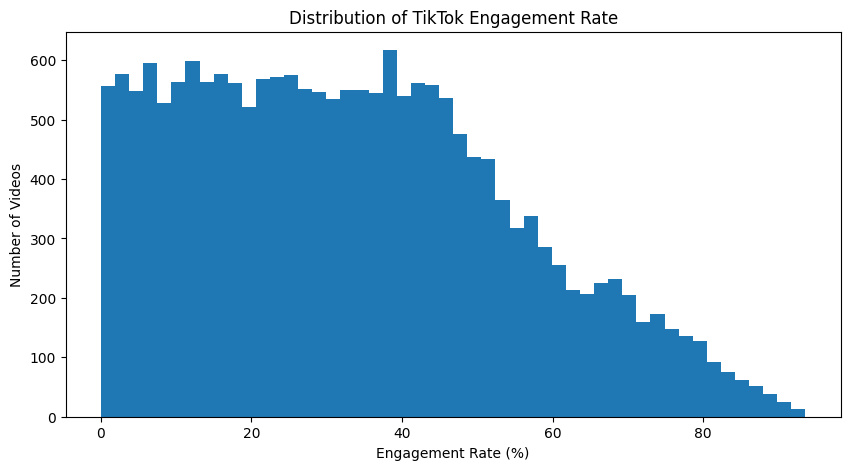

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    df_clean['engagement_rate'],
    bins=50
)

plt.xlabel('Engagement Rate (%)')
plt.ylabel('Number of Videos')
plt.title('Distribution of TikTok Engagement Rate')

plt.show()

In [ ]:
print("Mean Engagement Rate:",
      round(df_clean['engagement_rate'].mean(), 2), "%")

print("Median Engagement Rate:",
      round(df_clean['engagement_rate'].median(), 2), "%")

Mean Engagement Rate: 33.53 %
Median Engagement Rate: 31.84 %


In [ ]:
length_analysis = (
    df_clean
    .groupby('video_length_category', observed=True)
    .agg(
        videos=('video_id', 'count'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        median_engagement_rate=('engagement_rate', 'median'),
        avg_views=('video_view_count', 'mean')
    )
    .reset_index()
)

length_analysis

,video_length_category,videos,avg_engagement_rate,median_engagement_rate,avg_views
0,Short (≤15s),3836,33.179761,31.288777,251213.396507
1,Medium (16–30s),5047,33.531748,31.821413,257694.375471
2,Long (31–60s),10201,33.668435,32.119485,254545.635918


In [ ]:
length_analysis['avg_engagement_rate'] = (
    length_analysis['avg_engagement_rate'].round(2)
)

length_analysis['median_engagement_rate'] = (
    length_analysis['median_engagement_rate'].round(2)
)

length_analysis['avg_views'] = (
    length_analysis['avg_views'].round(0)
)

length_analysis

,video_length_category,videos,avg_engagement_rate,median_engagement_rate,avg_views
0,Short (≤15s),3836,33.18,31.29,251213.0
1,Medium (16–30s),5047,33.53,31.82,257694.0
2,Long (31–60s),10201,33.67,32.12,254546.0


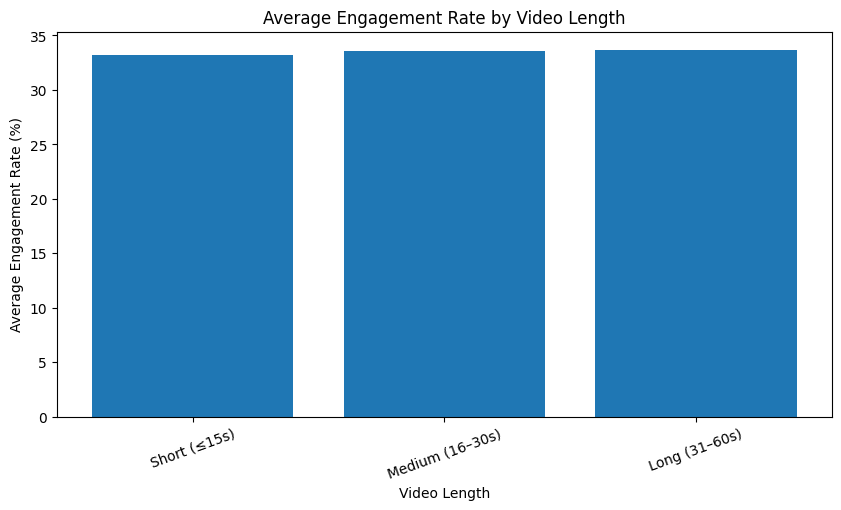

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    length_analysis['video_length_category'].astype(str),
    length_analysis['avg_engagement_rate']
)

plt.xlabel('Video Length')
plt.ylabel('Average Engagement Rate (%)')
plt.title('Average Engagement Rate by Video Length')
plt.xticks(rotation=20)

plt.show()

In [ ]:
verification_analysis = (
    df_clean
    .groupby('verified_status')
    .agg(
        videos=('video_id', 'count'),
        avg_views=('video_view_count', 'mean'),
        avg_engagement_rate=('engagement_rate', 'mean'),
        median_engagement_rate=('engagement_rate', 'median')
    )
    .reset_index()
)

verification_analysis

,verified_status,videos,avg_views,avg_engagement_rate,median_engagement_rate
0,not verified,17884,265663.785339,33.824896,32.155989
1,verified,1200,91439.164167,29.199637,28.337843


In [ ]:
verification_analysis['avg_views'] = (
    verification_analysis['avg_views'].round(0)
)

verification_analysis['avg_engagement_rate'] = (
    verification_analysis['avg_engagement_rate'].round(2)
)

verification_analysis['median_engagement_rate'] = (
    verification_analysis['median_engagement_rate'].round(2)
)

verification_analysis

,verified_status,videos,avg_views,avg_engagement_rate,median_engagement_rate
0,not verified,17884,265664.0,33.82,32.16
1,verified,1200,91439.0,29.20,28.34


In [ ]:
correlation = df_clean[
    [
        'video_view_count',
        'video_like_count',
        'video_share_count',
        'video_download_count',
        'video_comment_count',
        'total_engagement',
        'engagement_rate'
    ]
].corr()

correlation['engagement_rate'].sort_values(ascending=False)

,engagement_rate
engagement_rate,1.000000
total_engagement,0.612204
video_like_count,0.602112
video_share_count,0.567009
video_download_count,0.501888
video_comment_count,0.423479
video_view_count,0.247322


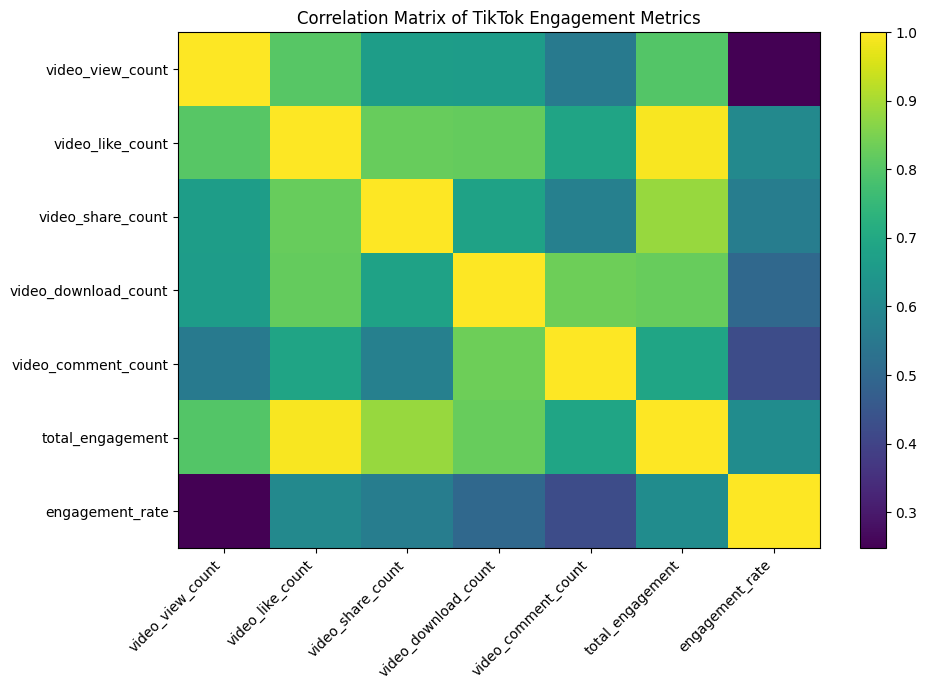

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(correlation, aspect='auto')

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.index)),
    correlation.index
)

plt.title('Correlation Matrix of TikTok Engagement Metrics')

plt.tight_layout()
plt.show()

In [ ]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Rows: 19084
Columns: 15

Missing values:
0

Duplicate rows:
0


In [ ]:
df_clean.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,total_engagement,engagement_rate,video_length_category
0,1,claim,7017666017,59,someone shared with me that drone deliveries are already happening and will become common by 2025,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,19667.0,5.728875,Long (31–60s)
1,2,claim,4014381136,32,someone shared with me that there are more microorganisms in one teaspoon of soil than people on...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,98234.0,69.730332,Long (31–60s)
2,3,claim,9859838091,31,someone shared with me that american industrialist andrew carnegie had a net worth of $475 milli...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,101710.0,11.273741,Long (31–60s)
3,4,claim,1866847991,25,"someone shared with me that the metro of st. petersburg, with an average depth of hundred meters...",not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,276584.0,63.218333,Medium (16–30s)
4,5,claim,7105231098,19,someone shared with me that the number of businesses allowing employees to bring pets to the wor...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,39796.0,70.852992,Medium (16–30s)


In [ ]:
df_clean.to_csv(
    'tiktok_clean.csv',
    index=False
)

In [ ]:
from google.colab import files

files.download('tiktok_clean.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>